<a href="https://colab.research.google.com/github/eyespydushyant/hotel-booking-price-prediction/blob/main/dushyant_Regression__ML_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/eyespydushyant/hotel-booking-price-prediction

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("/content/hotel_bookings.csv")

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 119390
Columns : 32


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 31994


#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing Values",ascending=False)

,Missing Values,Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00
arrival_date_month,0,0.00
arrival_date_week_number,0,0.00
hotel,0,0.00
is_canceled,0,0.00
stays_in_weekend_nights,0,0.00
arrival_date_day_of_month,0,0.00


In [24]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [11]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 31994


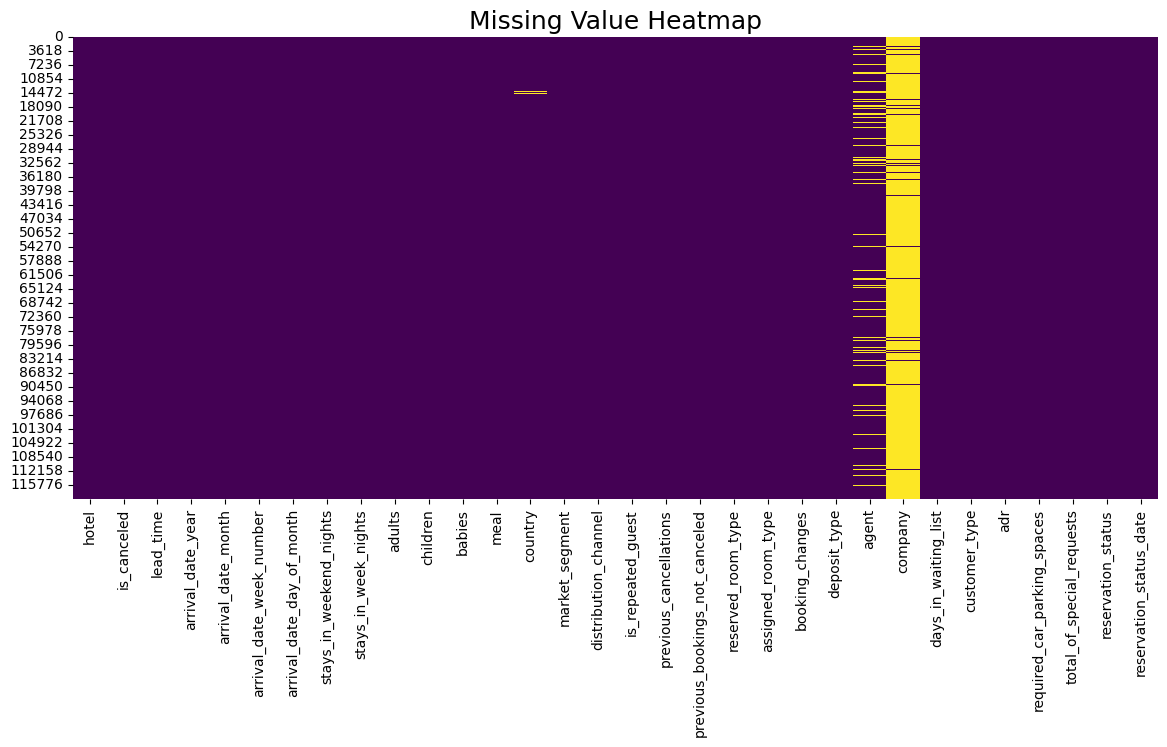

In [12]:
# Visualizing the missing values
plt.figure(figsize=(14,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Value Heatmap",fontsize=18)

plt.show()

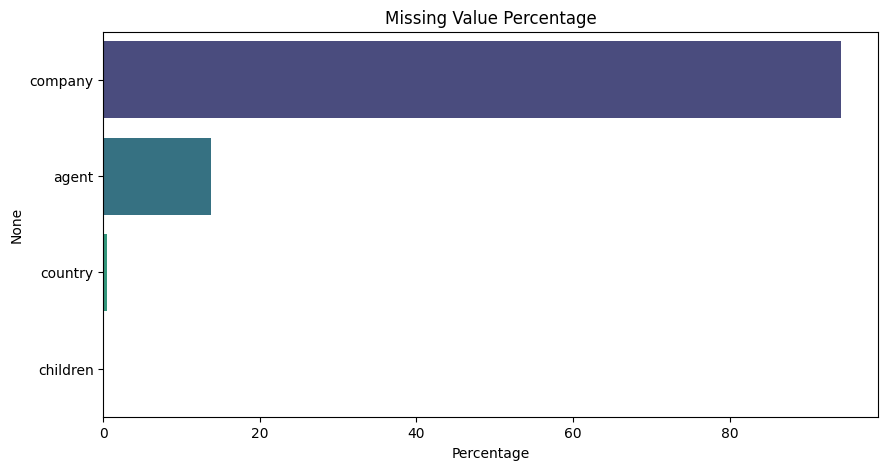

In [13]:
missing_percent=df.isnull().mean()*100

missing_percent=missing_percent[missing_percent>0]

missing_percent=missing_percent.sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=missing_percent.values,
            y=missing_percent.index,
            palette="viridis")

plt.xlabel("Percentage")

plt.title("Missing Value Percentage")

plt.show()

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [15]:
# Dataset Describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [16]:
# Check Unique Values for each variable.
unique_values=pd.DataFrame(df.nunique(),
                           columns=["Unique Values"])

unique_values.sort_values("Unique Values",
                          ascending=False)

,Unique Values
adr,8879
reservation_status_date,926
lead_time,479
company,352
agent,333
country,177
days_in_waiting_list,128
previous_bookings_not_canceled,73
arrival_date_week_number,53
stays_in_week_nights,35


## 3. ***Data Wrangling***

### Data Wrangling Code

In [17]:
# Write your code to make your dataset analysis ready.
df["adr"].describe()

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14

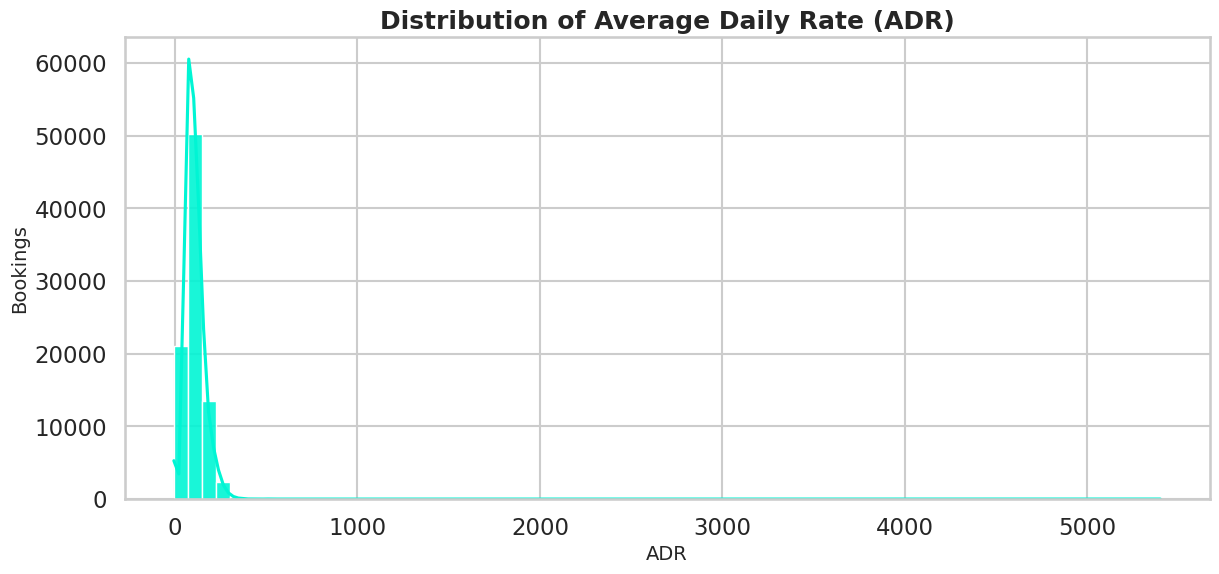

In [32]:
plt.figure(figsize=(14,6))

sns.histplot(
    data=df,
    x="adr",
    bins=70,
    kde=True,
    color="#00F5D4",
    edgecolor="white",
    alpha=0.9
)

plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR")
plt.ylabel("Bookings")

plt.show()

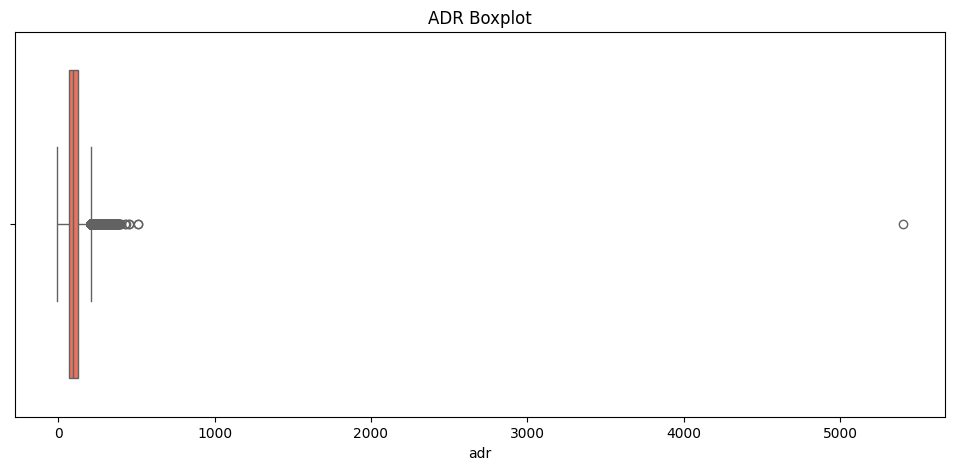

In [23]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df["adr"],
            color="tomato")

plt.title("ADR Boxplot")

plt.show()

In [44]:
# Children column
df["children"] = df["children"].fillna(df["children"].median())

# Country column
df["country"] = df["country"].fillna(df["country"].mode()[0])

# Agent column
df["agent"] = df["agent"].fillna(0)

# Company column
df["company"] = df["company"].fillna(0)

In [46]:
df["total_people"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

In [47]:
df[["adults", "children", "babies", "total_people"]].head()

,adults,children,babies,total_people
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


In [26]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [27]:
print("Duplicate Rows Before :", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After :", df.duplicated().sum())

Duplicate Rows Before : 32013
Duplicate Rows After : 0


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

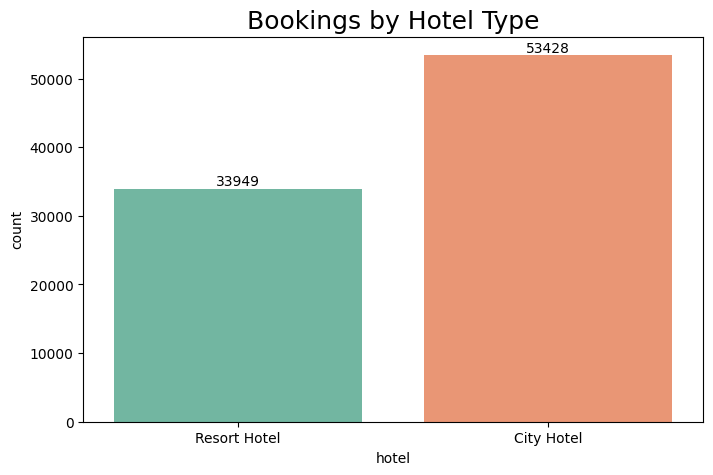

In [28]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="hotel",
    data=df,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Bookings by Hotel Type",fontsize=18)

plt.show()

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

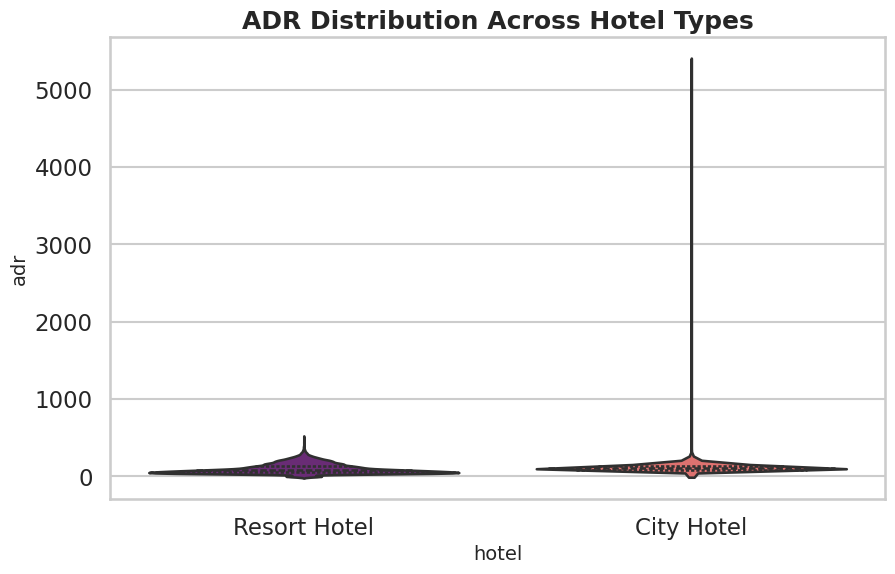

In [35]:
# Chart - 2 visualization code
plt.figure(figsize=(10,6))

sns.violinplot(
    x="hotel",
    y="adr",
    data=df,
    palette="magma",
    inner="quartile"
)

plt.title("ADR Distribution Across Hotel Types")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

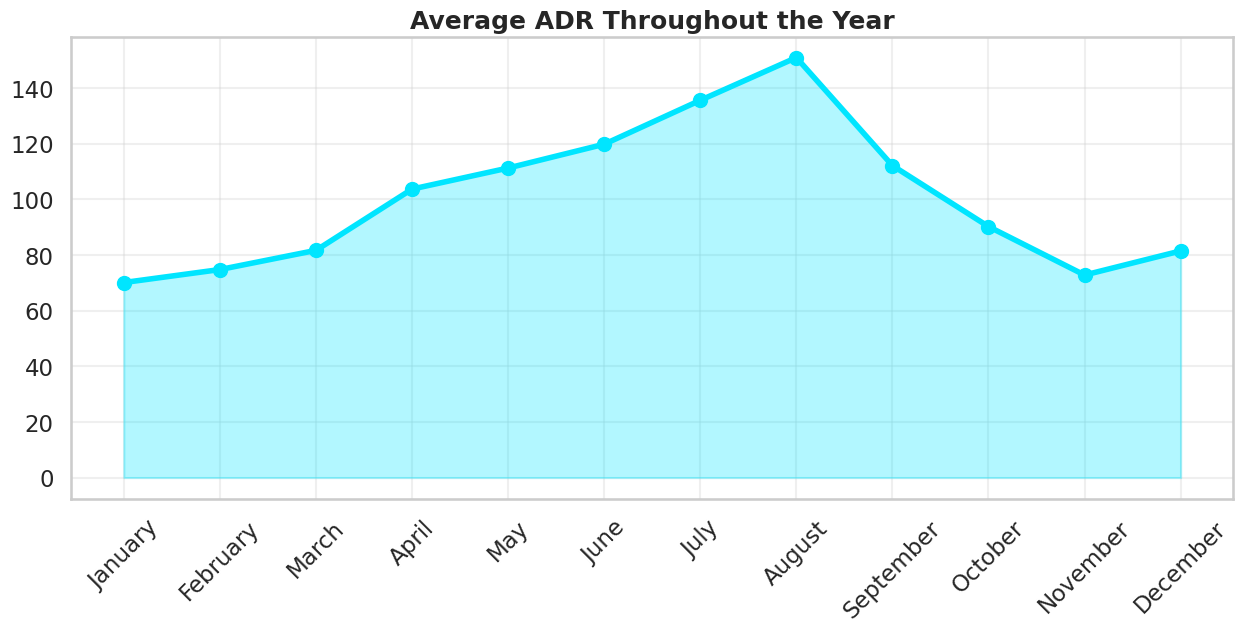

In [36]:
# Chart - 3 visualization code
monthly=df.groupby("arrival_date_month")["adr"].mean().reindex([
'January','February','March','April','May','June',
'July','August','September','October','November','December'
])

plt.figure(figsize=(15,6))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=4,
    markersize=10,
    color="#00E5FF"
)

plt.fill_between(
    monthly.index,
    monthly.values,
    alpha=0.3,
    color="#00E5FF"
)

plt.xticks(rotation=45)

plt.title("Average ADR Throughout the Year")

plt.grid(alpha=.3)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

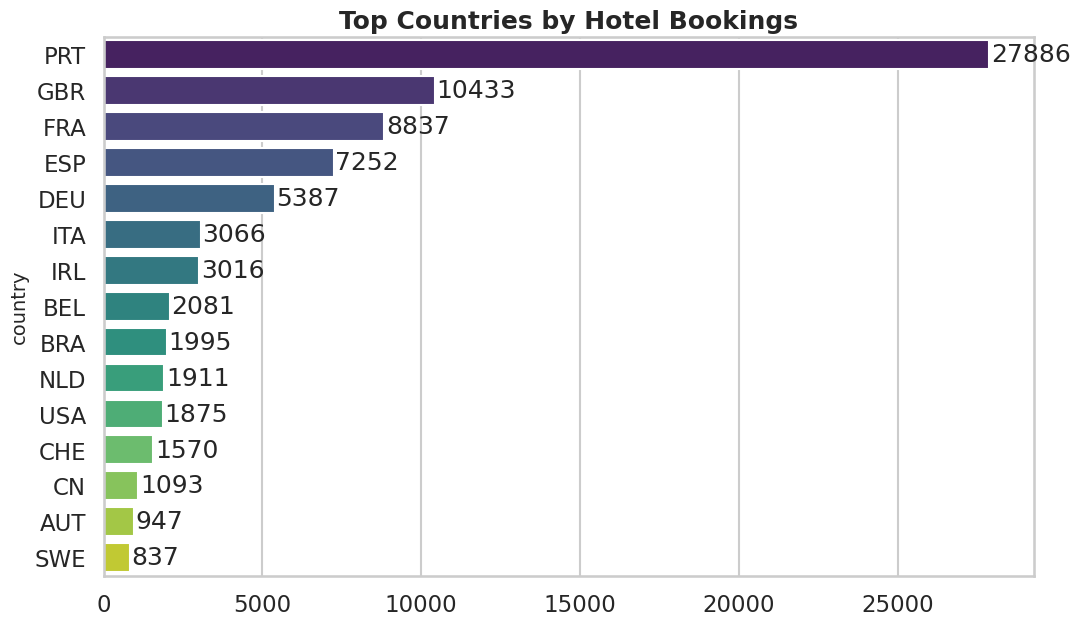

In [37]:
# Chart - 4 visualization code
country=df.country.value_counts().head(15)

plt.figure(figsize=(12,7))

colors=sns.color_palette("viridis",15)

ax=sns.barplot(
    x=country.values,
    y=country.index,
    palette=colors
)

for i,v in enumerate(country.values):
    plt.text(v+50,i,str(v),va="center")

plt.title("Top Countries by Hotel Bookings")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

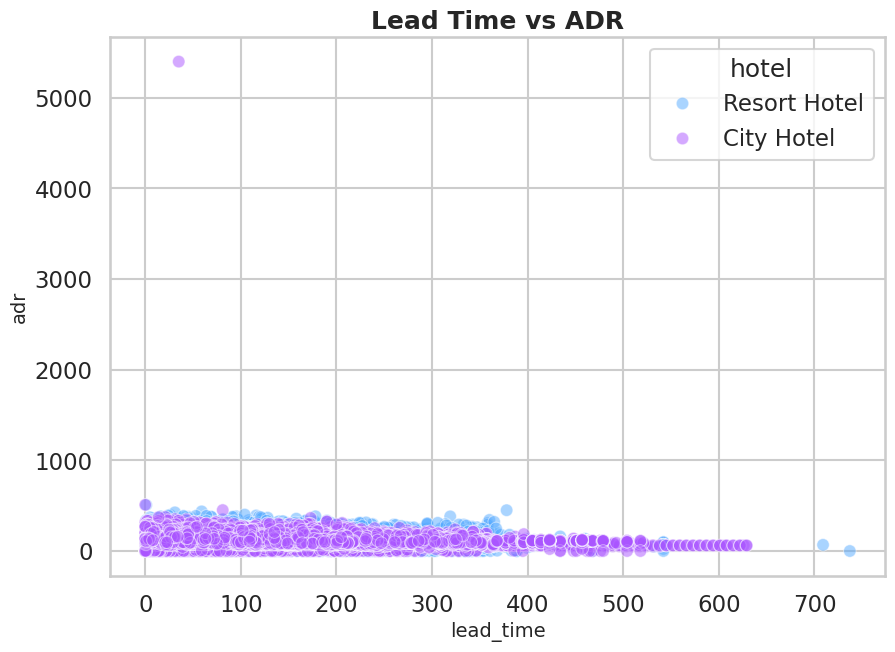

In [39]:
# Chart - 5 visualization code
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    hue="hotel",
    palette="cool",
    alpha=.5
)

plt.title("Lead Time vs ADR")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

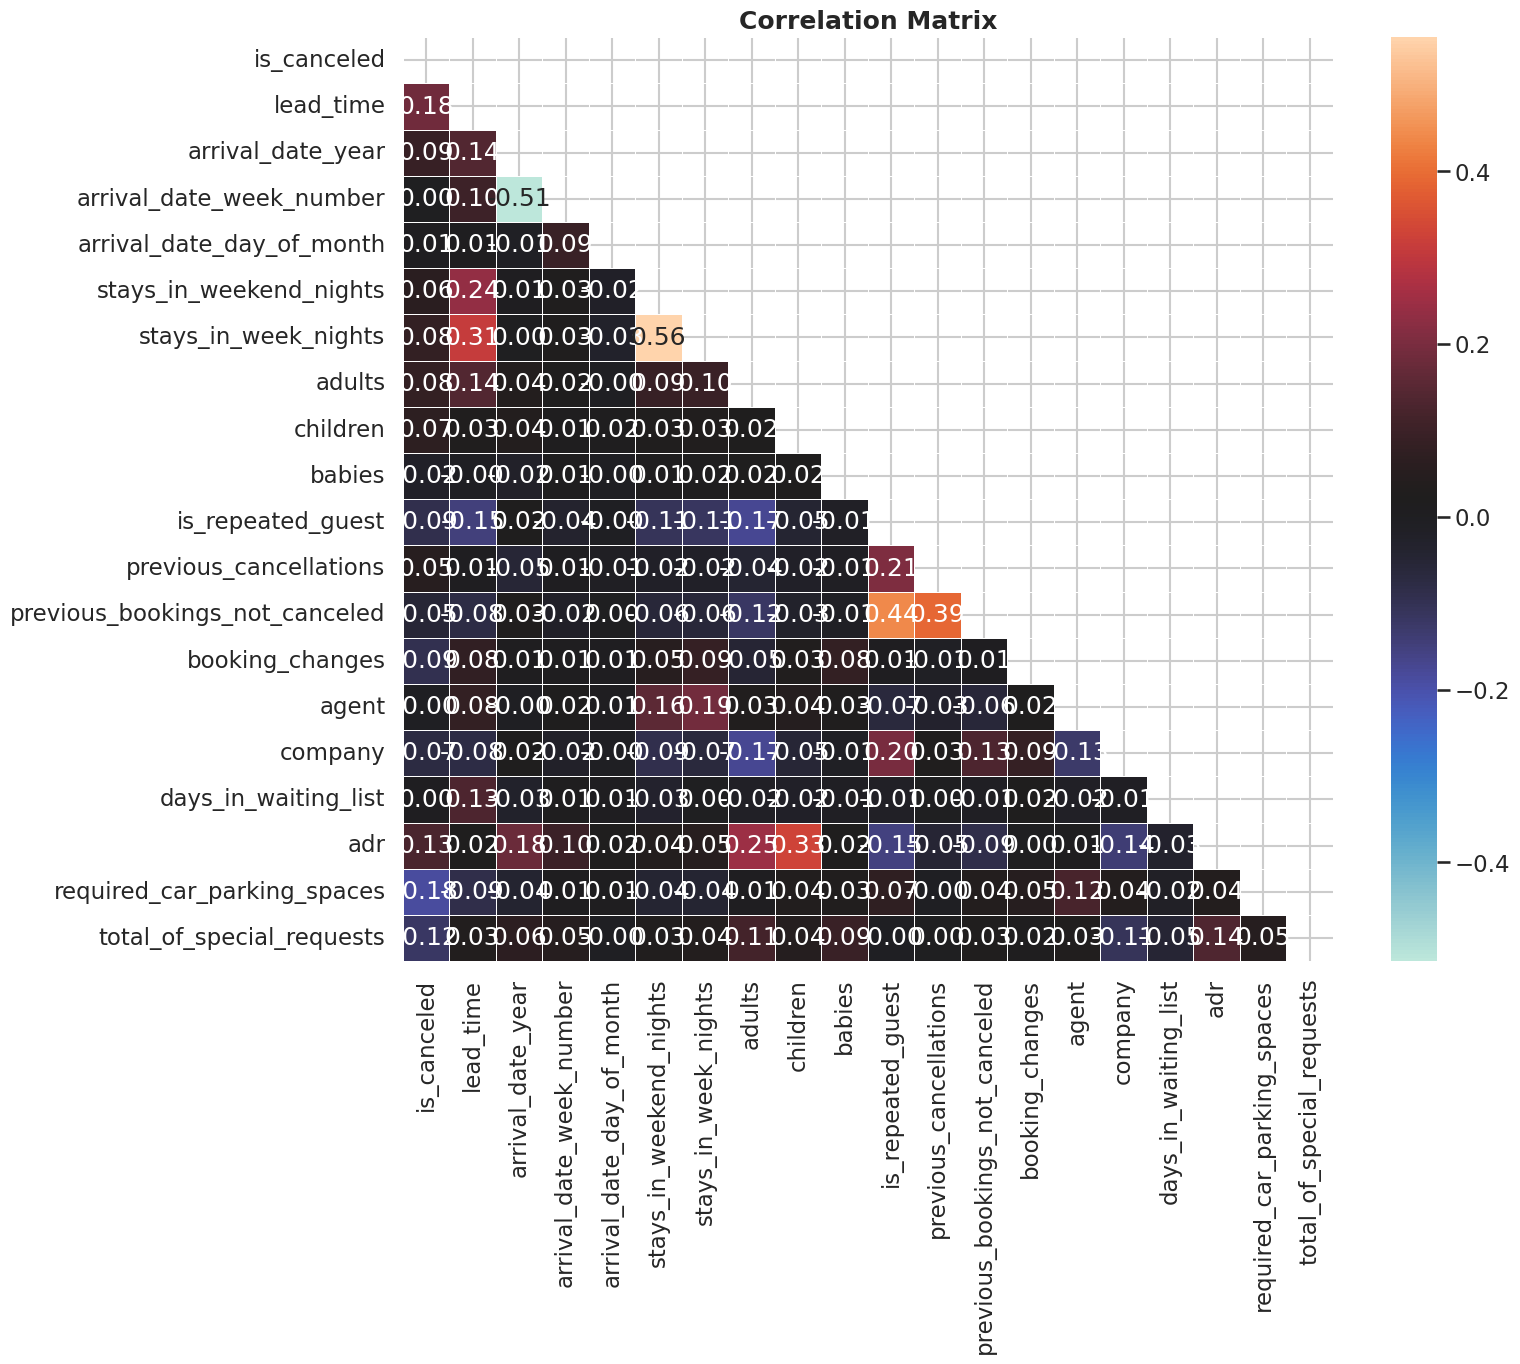

In [40]:
# Chart - 6 visualization code
corr=df.select_dtypes(include="number").corr()

plt.figure(figsize=(15,12))

mask=np.triu(corr)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="icefire",
    linewidth=.5
)

plt.title("Correlation Matrix")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

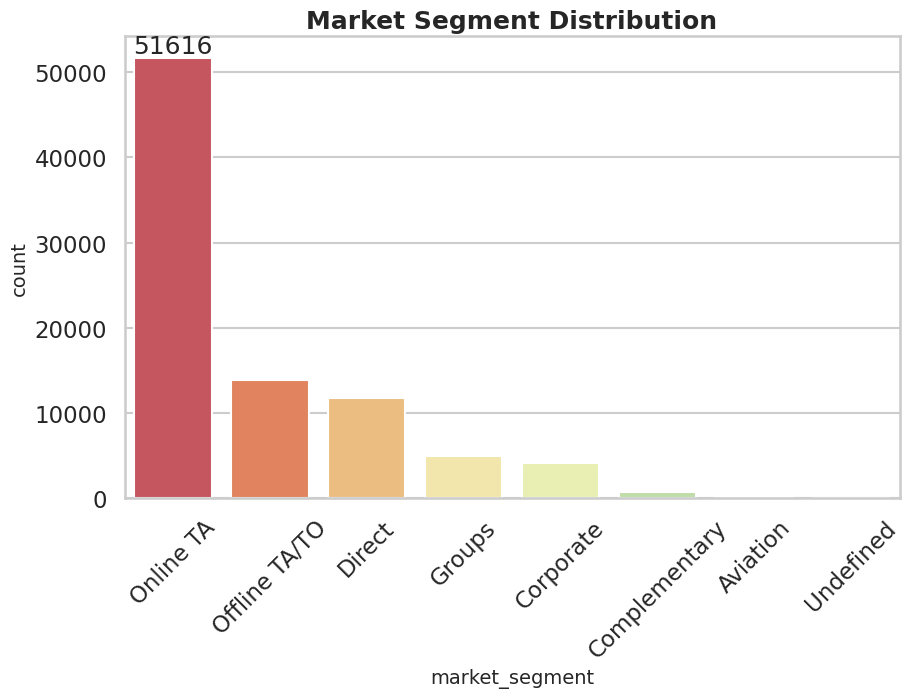

In [41]:
# Chart - 7 visualization code
plt.figure(figsize=(10,6))

ax=sns.countplot(
    data=df,
    x="market_segment",
    order=df.market_segment.value_counts().index,
    palette="Spectral"
)

ax.bar_label(ax.containers[0])

plt.xticks(rotation=45)

plt.title("Market Segment Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

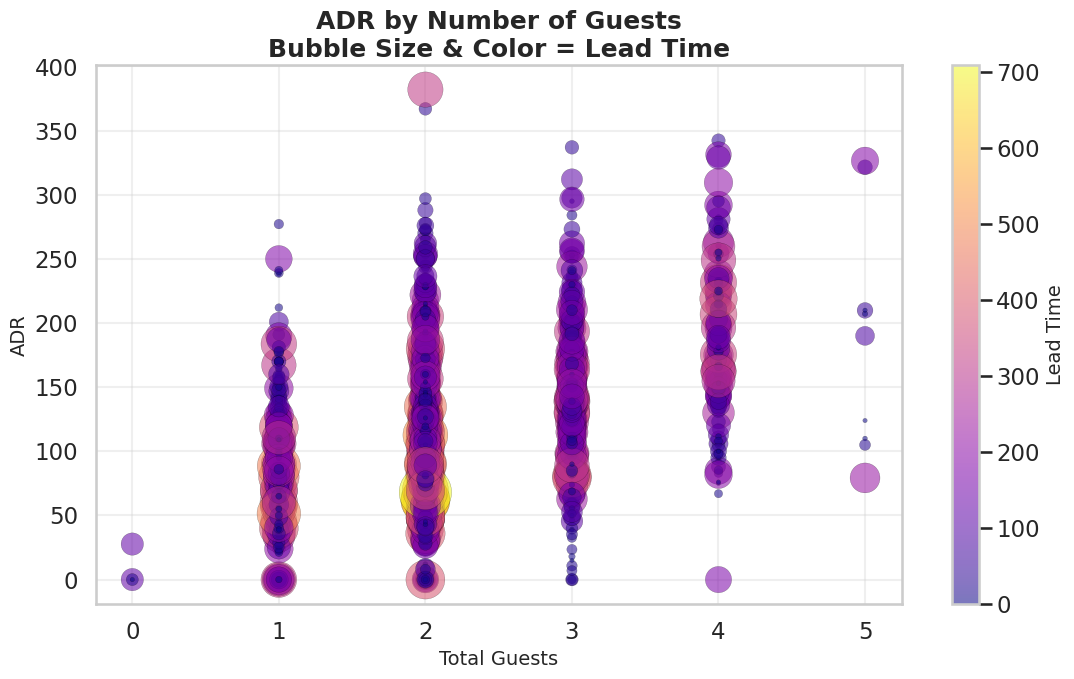

In [49]:
# Chart - 8 visualization code
sample_df = df.sample(4000, random_state=42)

plt.figure(figsize=(13,7))

sizes = (sample_df["lead_time"] + 5) * 2

scatter = plt.scatter(
    sample_df["total_people"],
    sample_df["adr"],
    s=sizes,
    c=sample_df["lead_time"],
    cmap="plasma",
    alpha=0.55,
    edgecolors="black",
    linewidth=0.2
)

plt.colorbar(scatter, label="Lead Time")

plt.xlabel("Total Guests")
plt.ylabel("ADR")
plt.title("ADR by Number of Guests\nBubble Size & Color = Lead Time")

plt.grid(alpha=0.3)

plt.show()

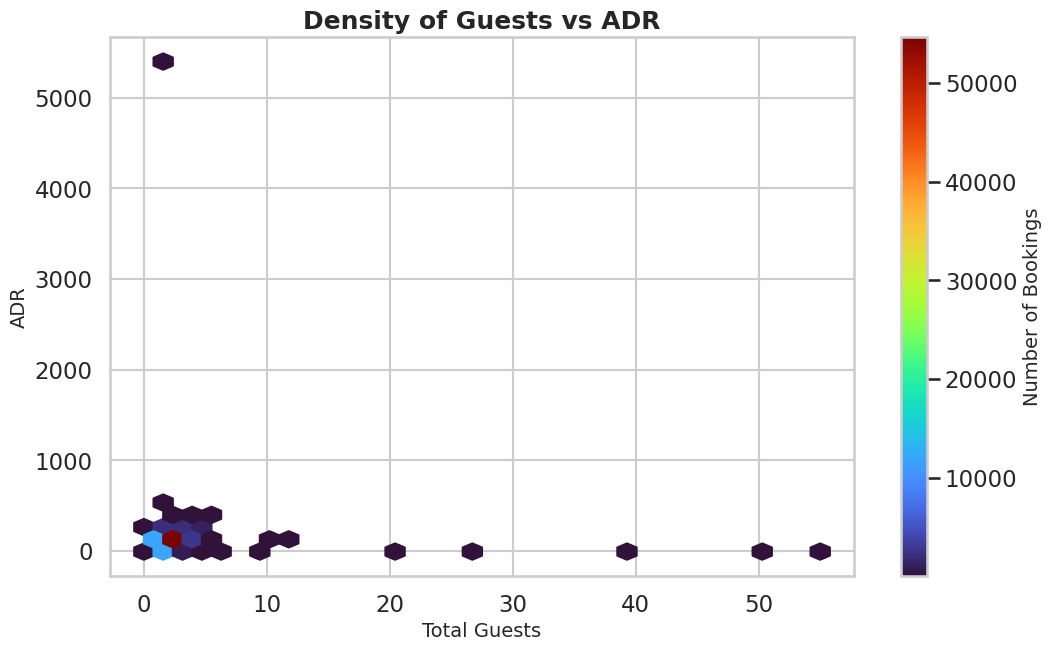

In [50]:
plt.figure(figsize=(12,7))

plt.hexbin(
    df["total_people"],
    df["adr"],
    gridsize=35,
    cmap="turbo",
    mincnt=1
)

plt.colorbar(label="Number of Bookings")

plt.xlabel("Total Guests")
plt.ylabel("ADR")

plt.title("Density of Guests vs ADR")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

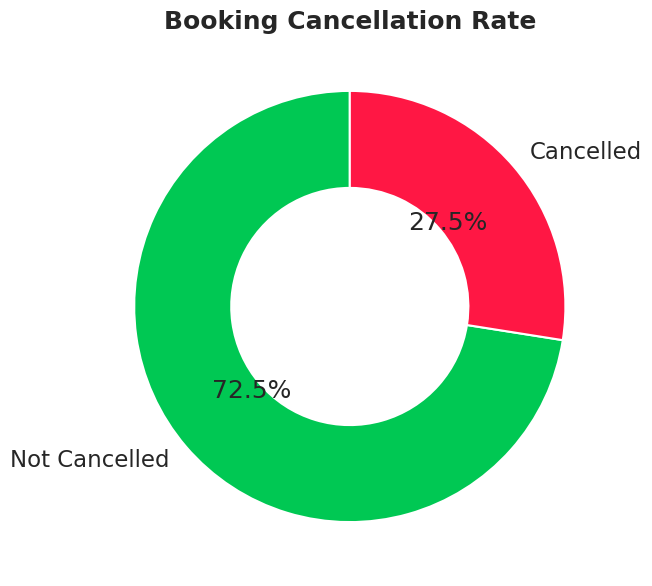

In [51]:
# Chart - 9 visualization code
cancel=df.is_canceled.value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    cancel,
    labels=["Not Cancelled","Cancelled"],
    autopct="%1.1f%%",
    colors=["#00C853","#FF1744"],
    wedgeprops=dict(width=0.45),
    startangle=90
)

plt.title("Booking Cancellation Rate")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

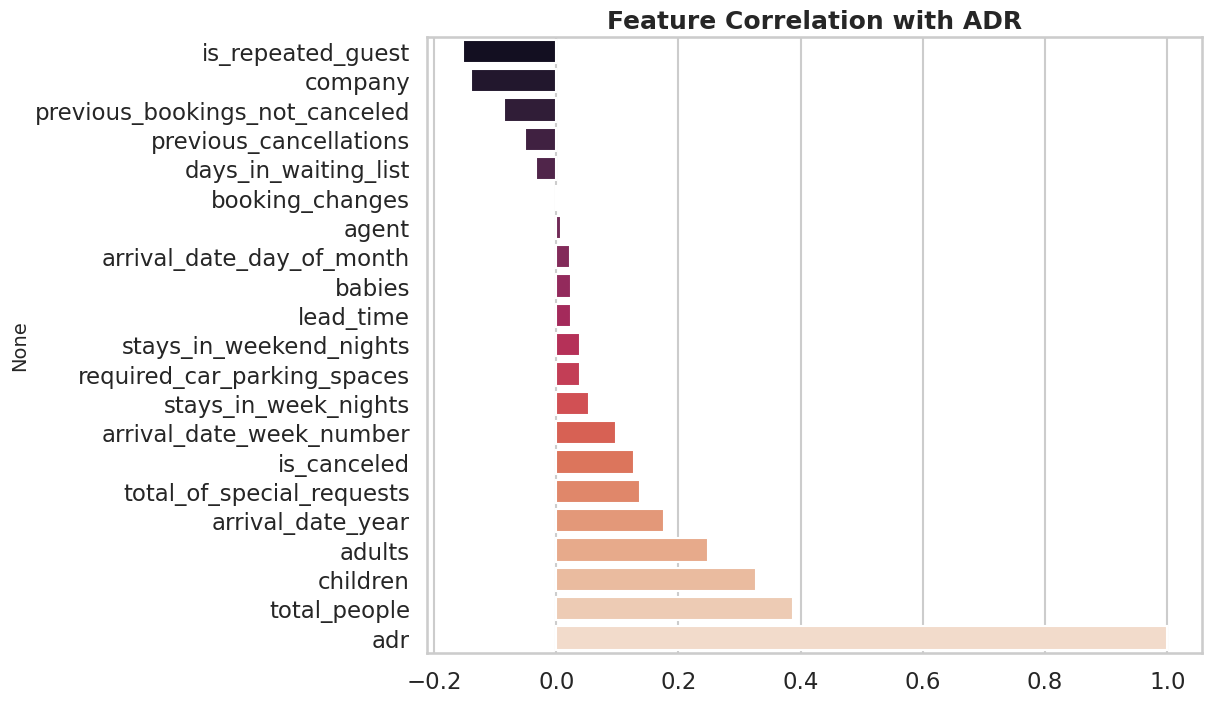

In [52]:
# Chart - 10 visualization code
corr=df.corr(numeric_only=True)["adr"].sort_values()

plt.figure(figsize=(10,8))

sns.barplot(
    x=corr.values,
    y=corr.index,
    palette="rocket"
)

plt.title("Feature Correlation with ADR")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

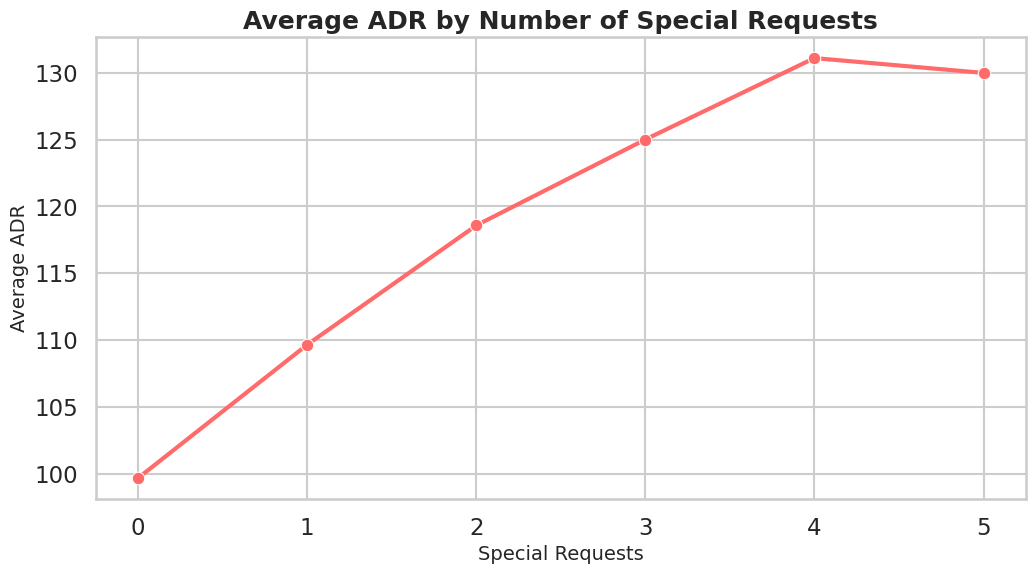

In [55]:
# Chart - 11 visualization code
plt.figure(figsize=(12,6))

special = df.groupby("total_of_special_requests")["adr"].mean().reset_index()

sns.lineplot(
    data=special,
    x="total_of_special_requests",
    y="adr",
    marker="o",
    linewidth=3,
    color="#ff6b6b"
)

plt.title("Average ADR by Number of Special Requests", fontsize=18)
plt.xlabel("Special Requests")
plt.ylabel("Average ADR")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

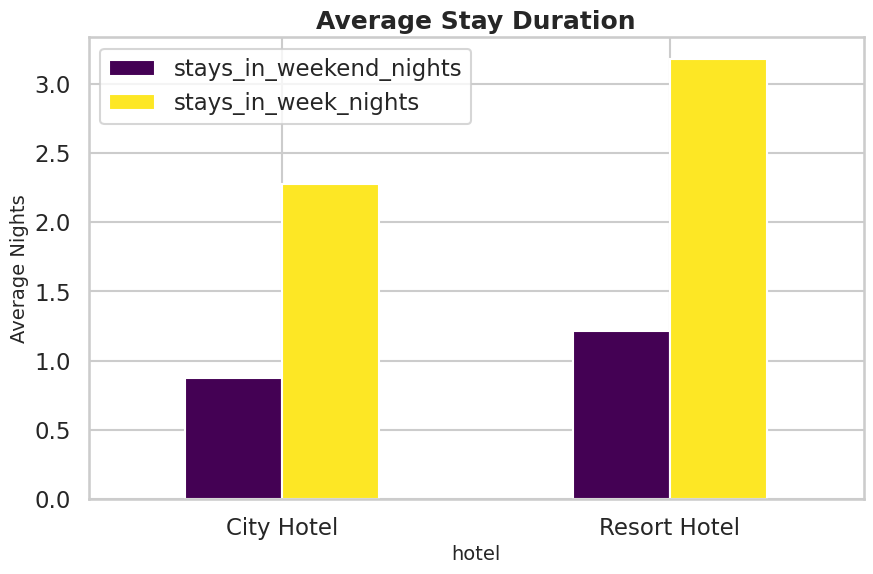

In [56]:
# Chart - 12 visualization code
stay = df.groupby("hotel")[["stays_in_weekend_nights",
                            "stays_in_week_nights"]].mean()

stay.plot(
    kind="bar",
    figsize=(10,6),
    colormap="viridis"
)

plt.title("Average Stay Duration")
plt.ylabel("Average Nights")
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

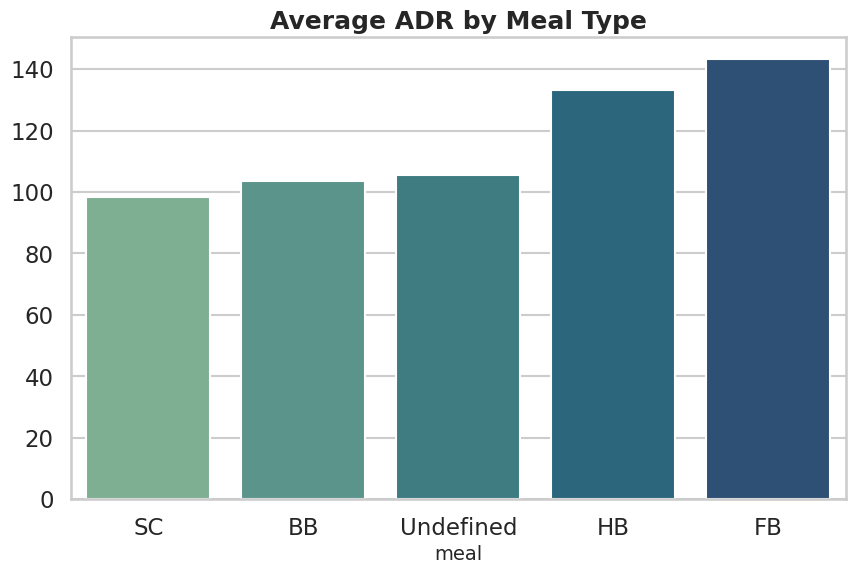

In [57]:
# Chart - 13 visualization code
meal = df.groupby("meal")["adr"].mean().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=meal.index,
    y=meal.values,
    palette="crest"
)

plt.title("Average ADR by Meal Type")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

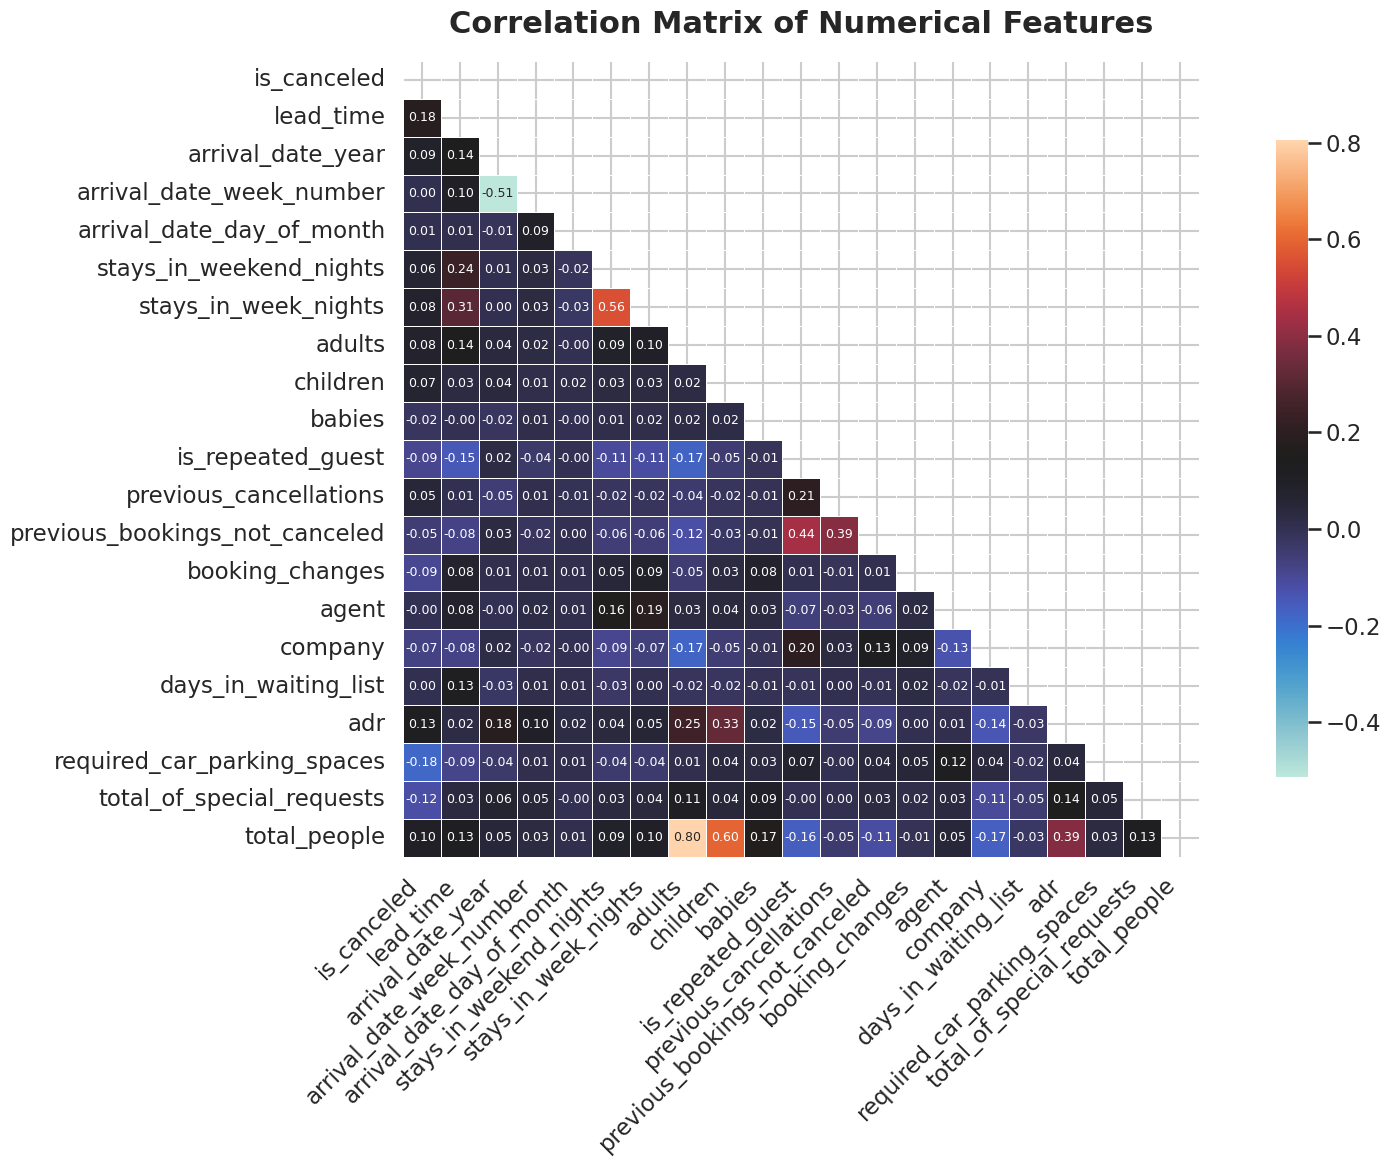

In [58]:
# Correlation Heatmap visualization code


corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    mask=mask,
    cmap="icefire",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":9}
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=22,
    weight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

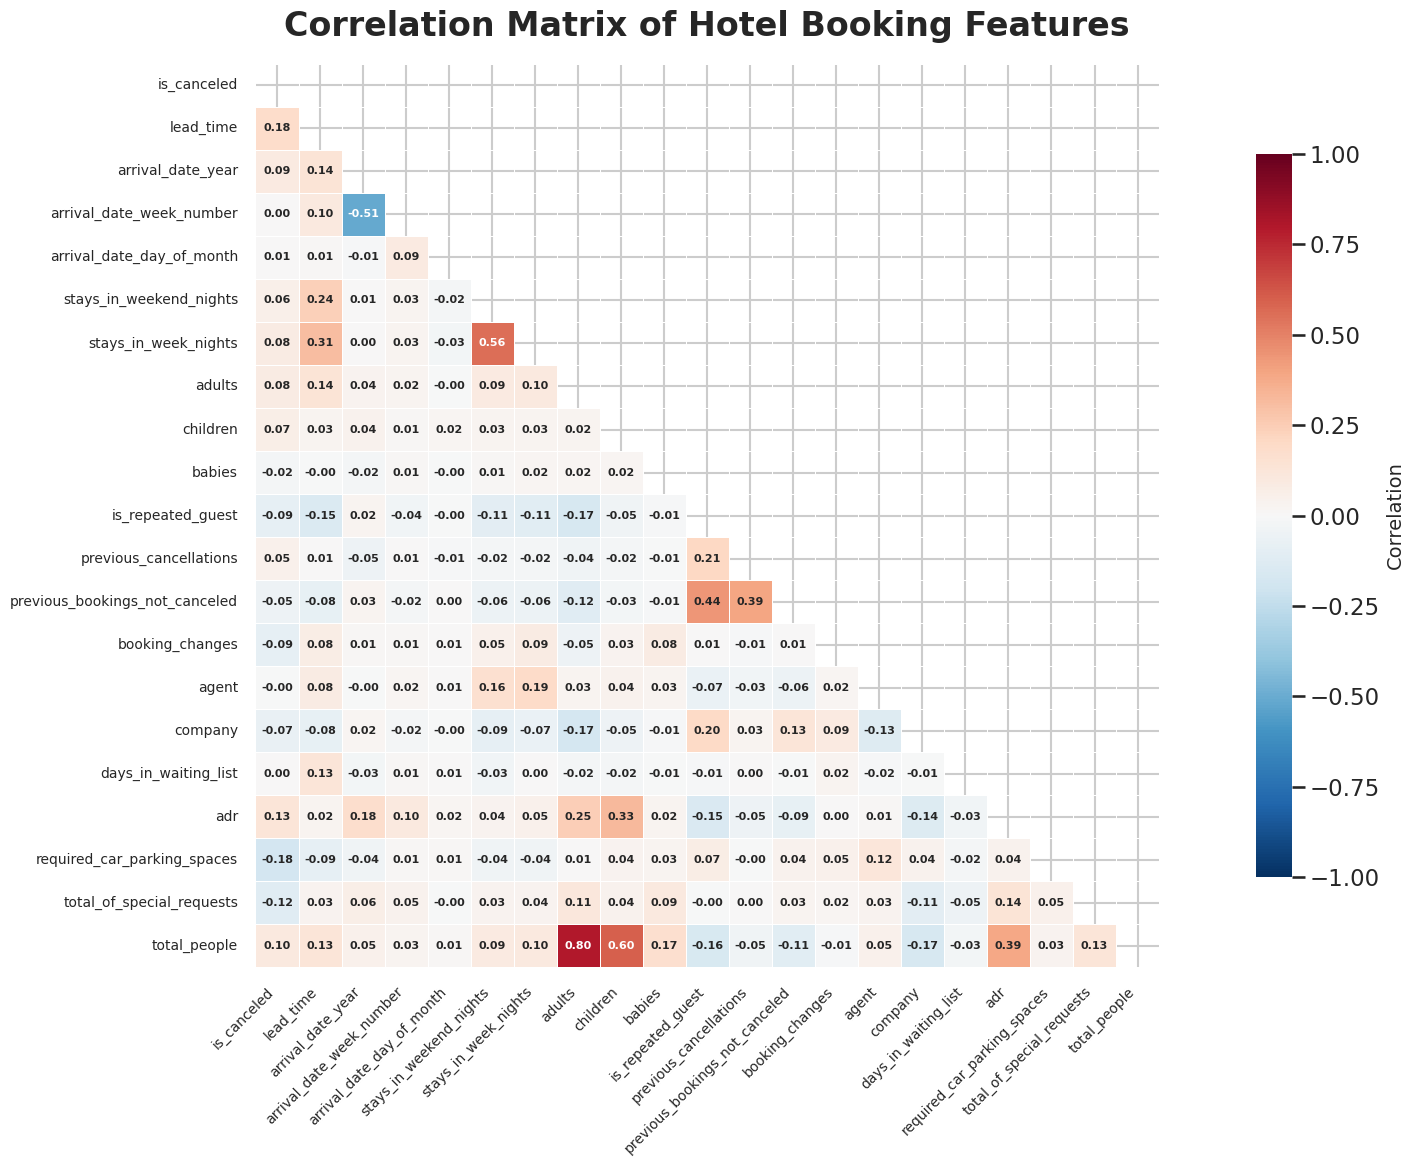

In [61]:
corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(20,12))

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmax=1,
    vmin=-1,
    annot=True,
    fmt=".2f",
    linewidths=.6,
    square=True,
    cbar_kws={
        "shrink":0.8,
        "label":"Correlation"
    },
    annot_kws={
        "size":8,
        "weight":"bold"
    }
)

plt.title(
    "Correlation Matrix of Hotel Booking Features",
    fontsize=24,
    weight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***